In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from scipy import stats


In [5]:
df=pd.read_csv("/content/machine_temperature_system_failure.csv")

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

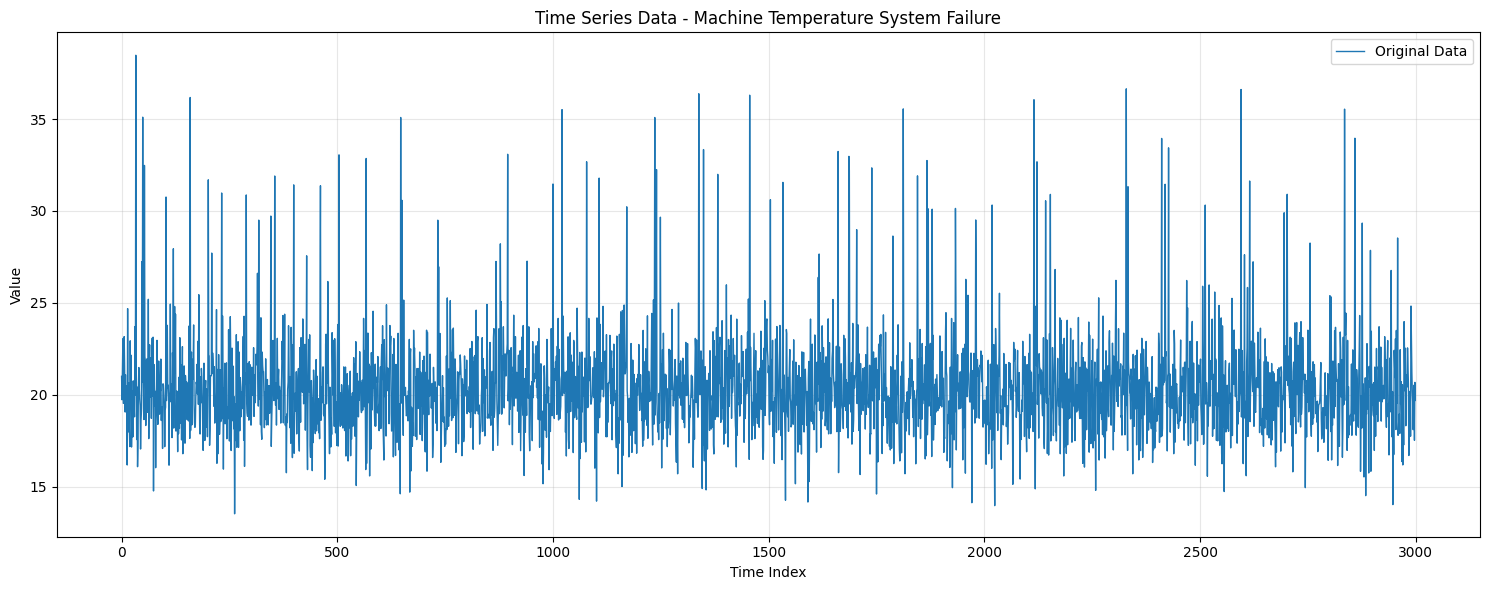

In [27]:
plt.figure(figsize=(15, 6))
plt.plot(time_series, label='Original Data', linewidth=1)
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)' if 'temperature' in value_column.lower() else 'Value')
plt.title('Time Series Data - Machine Temperature System Failure')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
max_df=df['value'].max()
print(max_df)
print(df['timestamp'])


108.5105428
0       2013-12-02 21:15:00
1       2013-12-02 21:20:00
2       2013-12-02 21:25:00
3       2013-12-02 21:30:00
4       2013-12-02 21:35:00
                ...        
22690   2014-02-19 15:05:00
22691   2014-02-19 15:10:00
22692   2014-02-19 15:15:00
22693   2014-02-19 15:20:00
22694   2014-02-19 15:25:00
Name: timestamp, Length: 22695, dtype: datetime64[ns]


In [10]:
min_row=df.loc[df['value'].idxmin()]
max_row=df.loc[df['value'].idxmax()]
mm_df=pd.DataFrame({

          'title':['minimum','maximum'],
          'value':[min_row['value'] , max_row['value']],
          'time':[min_row['timestamp'] , max_row['timestamp']]

})

print(mm_df)


     title       value                time
0  minimum    2.084721 2013-12-16 17:25:00
1  maximum  108.510543 2013-12-26 15:45:00


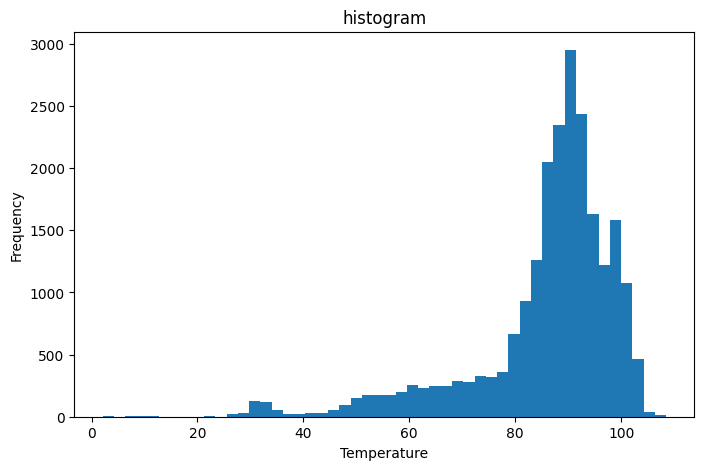

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['value'], bins=50)
plt.title("histogram")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

In [12]:
np.random.seed(42)
timestamps = pd.date_range(start='2013-12-01', periods=3000, freq='5T')
normal_data = np.random.normal(loc=20, scale=2, size=3000)

/tmp/ipykernel_1005/3861892129.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start='2013-12-01', periods=3000, freq='5T')


In [13]:
anomaly_indices = np.random.choice(3000, size=100, replace=False)
normal_data[anomaly_indices] = np.random.normal(loc=30, scale=5, size=100)


In [14]:
df = pd.DataFrame({
        'timestamp': timestamps,
        'value': normal_data,
        'anomaly': 0
    })
df.loc[anomaly_indices, 'anomaly'] = 1
print("Created sample data for demonstration")

Created sample data for demonstration


In [15]:
df.info()
df.describe()
df.columns
df.head()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3000 non-null   datetime64[ns]
 1   value      3000 non-null   float64       
 2   anomaly    3000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 70.4 KB


,0
timestamp,0
value,0
anomaly,0


In [16]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
elif 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)


In [20]:
value_column = df.columns[1] if len(df.columns) > 1 else 'value'



In [19]:
df[value_column] = df[value_column].fillna(df[value_column].interpolate())

In [21]:
time_series = df[value_column].values.reshape(-1, 1)

In [24]:
scaler = StandardScaler()
time_series_scaled = scaler.fit_transform(time_series)

print(f"\nData shape after preprocessing: {time_series_scaled.shape}")
print(f"Mean after scaling: {time_series_scaled.mean():.4f}")
print(f"Std after scaling: {time_series_scaled.std():.4f}")


Data shape after preprocessing: (3000, 1)
Mean after scaling: 0.0000
Std after scaling: 1.0000


In [29]:
def detect_anomalies_zscore(data, threshold=3):
  z_scores = np.abs(stats.zscore(data))
  anomalies = z_scores > threshold
  return anomalies, z_scores


In [30]:
z_score_anomalies, z_scores = detect_anomalies_zscore(time_series.flatten(), threshold=3)
print(f"\nZ-Score Method: Detected {z_score_anomalies.sum()} anomalies")


Z-Score Method: Detected 64 anomalies


In [31]:
def detect_anomalies_isolation_forest(data, contamination=0.05):

    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )

    predictions = iso_forest.fit_predict(data)
    scores = iso_forest.score_samples(data)

    anomalies = predictions == -1

    return anomalies, scores, iso_forest

iso_anomalies, iso_scores, iso_model = detect_anomalies_isolation_forest(
    time_series_scaled,
    contamination=0.05
)
print(f"Isolation Forest: Detected {iso_anomalies.sum()} anomalies")

Isolation Forest: Detected 148 anomalies


In [32]:

def create_lstm_autoencoder(sequence_length, threshold_percentile=95):


    inputs = keras.Input(shape=(sequence_length, 1))


    encoded = layers.LSTM(32, activation='relu', return_sequences=False)(inputs)


    decoded = layers.RepeatVector(sequence_length)(encoded)


    decoded = layers.LSTM(32, activation='relu', return_sequences=True)(decoded)
    decoded = layers.TimeDistributed(layers.Dense(1))(decoded)

    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

In [33]:
def create_sequences(data, sequence_length=50):

    X = []
    for i in range(len(data) - sequence_length + 1):
        X.append(data[i:i + sequence_length])
    return np.array(X)

sequence_length = 50
X_sequences = create_sequences(time_series_scaled, sequence_length)

print(f"\nLSTM Autoencoder - Sequence shape: {X_sequences.shape}")


LSTM Autoencoder - Sequence shape: (2951, 50, 1)


In [34]:
autoencoder = create_lstm_autoencoder(sequence_length)
print(autoencoder.summary())


print("\nTraining LSTM Autoencoder...")
history = autoencoder.fit(
    X_sequences,
    X_sequences,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

print("Training complete!")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM Autoencoder...
Training complete!


In [35]:
train_predictions = autoencoder.predict(X_sequences)
mse_loss = np.mean(np.square(X_sequences - train_predictions), axis=(1, 2))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


In [36]:
threshold = np.percentile(mse_loss, 95)
print(f"Reconstruction error threshold (95th percentile): {threshold:.4f}")

Reconstruction error threshold (95th percentile): 1.5826


In [37]:
lstm_anomalies = np.zeros(len(time_series_scaled))
lstm_anomalies[sequence_length-1:sequence_length-1+len(mse_loss)] = mse_loss > threshold

print(f"LSTM Autoencoder: Detected {lstm_anomalies.sum()} anomalies")

LSTM Autoencoder: Detected 148.0 anomalies


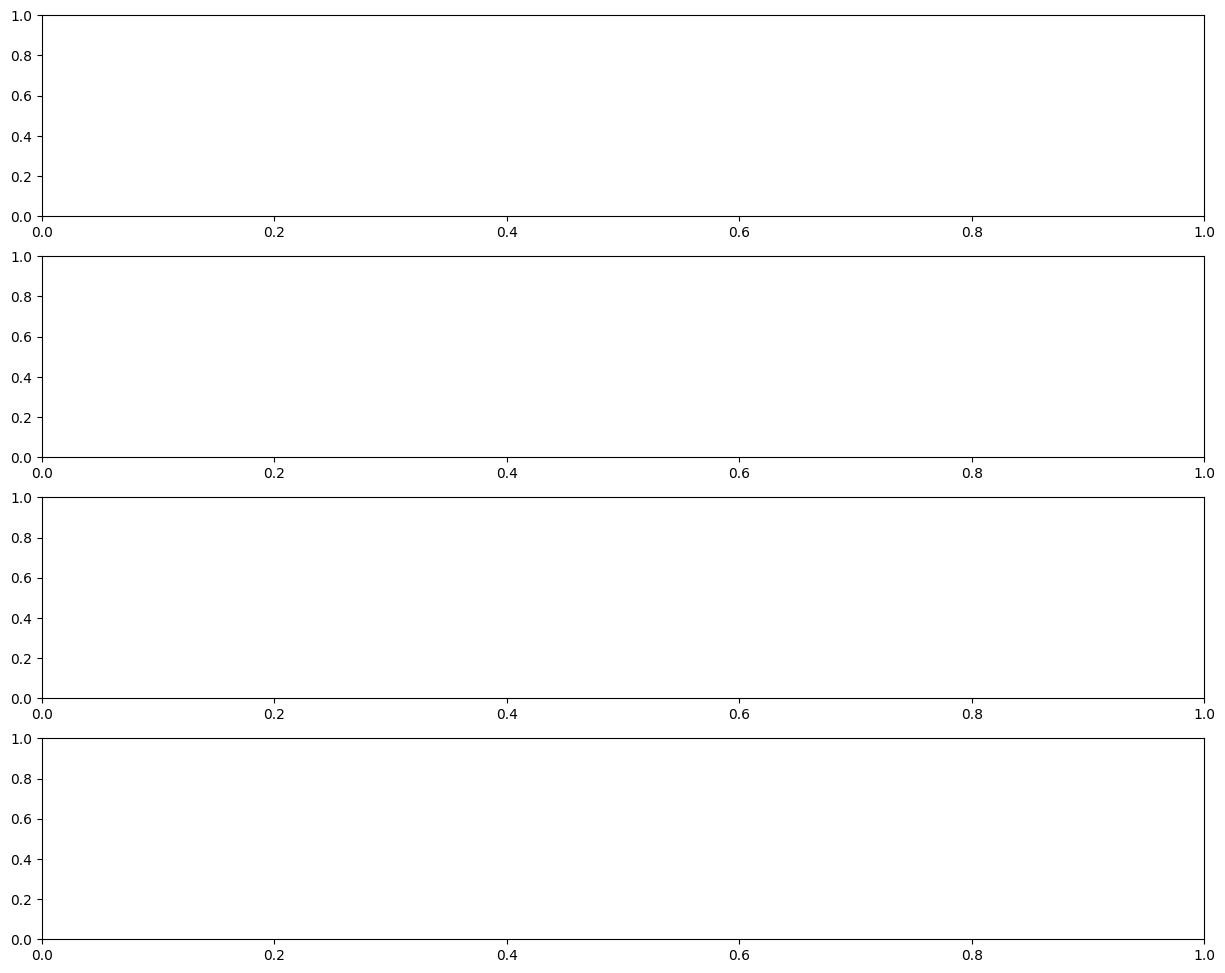

In [38]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

In [39]:
axes[0].plot(time_series, label='Temperature', linewidth=1, color='blue')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Original Time Series')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

In [40]:
axes[1].plot(time_series, label='Temperature', linewidth=1, color='blue')
anomaly_indices = np.where(z_score_anomalies)[0]
axes[1].scatter(anomaly_indices, time_series[anomaly_indices],
                color='red', label='Anomalies', s=20)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Z-Score Anomaly Detection')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

In [41]:
axes[2].plot(time_series, label='Temperature', linewidth=1, color='blue')
anomaly_indices = np.where(iso_anomalies)[0]
axes[2].scatter(anomaly_indices, time_series[anomaly_indices],
                color='red', label='Anomalies', s=20)
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_title('Isolation Forest Anomaly Detection')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# LSTM Autoencoder
axes[3].plot(time_series, label='Temperature', linewidth=1, color='blue')
anomaly_indices = np.where(lstm_anomalies)[0]
axes[3].scatter(anomaly_indices, time_series[anomaly_indices],
                color='red', label='Anomalies', s=20)
axes[3].set_xlabel('Time Index')
axes[3].set_ylabel('Temperature (°C)')
axes[3].set_title('LSTM Autoencoder Anomaly Detection')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [42]:
def ensemble_anomaly_detection(iso_anom, lstm_anom, zscore_anom, voting_threshold=2):

    votes = iso_anom.astype(int) + lstm_anom.astype(int) + zscore_anom.astype(int)
    ensemble_predictions = votes >= voting_threshold
    confidence = votes / 3.0

    return ensemble_predictions, confidence


min_len = min(len(z_score_anomalies), len(iso_anomalies), len(lstm_anomalies))
ensemble_pred, ensemble_conf = ensemble_anomaly_detection(
    iso_anomalies[:min_len],
    lstm_anomalies[:min_len],
    z_score_anomalies[:min_len],
    voting_threshold=2
)

print(f"\nEnsemble Method: Detected {ensemble_pred.sum()} anomalies")


Ensemble Method: Detected 71 anomalies


In [43]:
axes[0].plot(z_scores, linewidth=1, color='blue', label='Z-Score')
axes[0].axhline(y=3, color='red', linestyle='--', label='Threshold (3)')
axes[0].fill_between(range(len(z_scores)), 3, max(z_scores.max(), 4),
                      alpha=0.2, color='red', label='Anomaly Zone')
axes[0].set_ylabel('Z-Score')
axes[0].set_title('Z-Score Anomaly Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Isolation Forest scores
axes[1].plot(iso_scores, linewidth=1, color='green', label='Isolation Forest Score')
axes[1].axhline(y=iso_scores[iso_anomalies].max(), color='red', linestyle='--',
                label='Anomaly Threshold')
axes[1].fill_between(range(len(iso_scores)), iso_scores[iso_anomalies].max(),
                      iso_scores.min(), alpha=0.2, color='red', label='Anomaly Zone')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Isolation Forest Anomaly Scores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LSTM reconstruction error
axes[2].plot(np.arange(sequence_length-1, sequence_length-1+len(mse_loss)),
             mse_loss, linewidth=1, color='purple', label='Reconstruction Error')
axes[2].axhline(y=threshold, color='red', linestyle='--', label='Threshold')
axes[2].fill_between(np.arange(sequence_length-1, sequence_length-1+len(mse_loss)),
                     threshold, mse_loss.max(), alpha=0.2, color='red',
                     label='Anomaly Zone')
axes[2].set_xlabel('Time Index')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('LSTM Autoencoder Reconstruction Error')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [44]:
if 'anomaly' in df.columns or 'label' in df.columns:
    true_labels = df['anomaly'].values[:min_len] if 'anomaly' in df.columns else \
                  df['label'].values[:min_len]

    print("\n" + "="*60)
    print("EVALUATION METRICS (Comparing with Ground Truth)")
    print("="*60)

    # Isolation Forest
    print("\n--- Isolation Forest ---")
    print(classification_report(true_labels, iso_anomalies[:min_len],
                                target_names=['Normal', 'Anomaly']))
    print(f"ROC-AUC Score: {roc_auc_score(true_labels, 1 - iso_scores[:min_len]):.4f}")

    # Z-Score
    print("\n--- Z-Score ---")
    print(classification_report(true_labels, z_score_anomalies[:min_len],
                                target_names=['Normal', 'Anomaly']))

    # LSTM
    print("\n--- LSTM Autoencoder ---")
    print(classification_report(true_labels, lstm_anomalies[:min_len],
                                target_names=['Normal', 'Anomaly']))

    # Ensemble
    print("\n--- Ensemble (Voting) ---")
    print(classification_report(true_labels, ensemble_pred,
                                target_names=['Normal', 'Anomaly']))


EVALUATION METRICS (Comparing with Ground Truth)

--- Isolation Forest ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      2900
     Anomaly       0.58      0.86      0.69       100

    accuracy                           0.97      3000
   macro avg       0.79      0.92      0.84      3000
weighted avg       0.98      0.97      0.98      3000

ROC-AUC Score: 0.9713

--- Z-Score ---
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      2900
     Anomaly       1.00      0.64      0.78       100

    accuracy                           0.99      3000
   macro avg       0.99      0.82      0.89      3000
weighted avg       0.99      0.99      0.99      3000


--- LSTM Autoencoder ---
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96      2900
     Anomaly       0.07      0.10      0.08       100

    accuracy                           0.

In [45]:
results_df = pd.DataFrame({
    'Z_Score_Anomaly': z_score_anomalies[:min_len],
    'Isolation_Forest_Anomaly': iso_anomalies[:min_len],
    'LSTM_Anomaly': lstm_anomalies[:min_len],
    'Ensemble_Anomaly': ensemble_pred,
    'Ensemble_Confidence': ensemble_conf,
    'Original_Value': time_series[:min_len].flatten()
})

results_df.to_csv('anomaly_detection_results.csv', index=False)
print("\nResults saved to 'anomaly_detection_results.csv'")
autoencoder.save('lstm_autoencoder_model.h5')
print("LSTM model saved to 'lstm_autoencoder_model.h5'")



Results saved to 'anomaly_detection_results.csv'
LSTM model saved to 'lstm_autoencoder_model.h5'


In [46]:
import pickle
with open('isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(iso_model, f)
print("Isolation Forest model saved to 'isolation_forest_model.pkl'")

Isolation Forest model saved to 'isolation_forest_model.pkl'


In [47]:
print("\n" + "="*60)
print("SUMMARY OF ANOMALY DETECTION METHODS")
print("="*60)

summary_data = {
    'Method': ['Z-Score', 'Isolation Forest', 'LSTM Autoencoder', 'Ensemble'],
    'Anomalies Detected': [
        z_score_anomalies.sum(),
        iso_anomalies.sum(),
        lstm_anomalies.sum(),
        ensemble_pred.sum()
    ],
    'Complexity': ['Very Low', 'Low', 'High', 'Medium'],
    'Best For': [
        'Quick baseline, assumes normal distribution',
        'General-purpose, handles non-linear patterns',
        'Complex patterns, requires training',
        'Robust predictions, reduces false positives'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


SUMMARY OF ANOMALY DETECTION METHODS
          Method  Anomalies Detected Complexity                                     Best For
         Z-Score                64.0   Very Low  Quick baseline, assumes normal distribution
Isolation Forest               148.0        Low General-purpose, handles non-linear patterns
LSTM Autoencoder               148.0       High          Complex patterns, requires training
        Ensemble                71.0     Medium  Robust predictions, reduces false positives
